<a href="https://colab.research.google.com/github/jadstronaute/Projet_GPI_JE/blob/main/GPI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Projet de gestion de projet indormatique

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tifffile as tif
from scipy import ndimage

from PIL import Image
import importlib.util
import subprocess
import sys
import requests
from io import BytesIO  # Ensure this import is present

from skimage import io, transform
from scipy.signal import correlate2d

import urllib.request
#import io
%pip install Bio
from Bio.PDB import PDBParser, PDBIO
from mpl_toolkits.mplot3d import Axes3D


# Ensure scikit-image is available for bilateral denoising.
if importlib.util.find_spec('skimage') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'scikit-image'])

from skimage.restoration import denoise_bilateral


# Install required package (run once)
%pip install mrcfile

import mrcfile

# %pip install gdown

import gdown
import mrcfile
import os

# if needed, you can install packages using pip
# %pip install scikit-image

# Set random seed for reproducibility
np.random.seed(42)

print("yippeeeee")

yippeeeee


Now to import the mrc files from google drive, if you wanna import something else just change the ID

Downloading...
From (original): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr
From (redirected): https://drive.google.com/uc?id=1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr&confirm=t&uuid=5238522d-0262-4cd0-a6e5-2631b8e87f22
To: /content/map.mrc
100%|██████████| 228M/228M [00:02<00:00, 98.7MB/s]
/usr/local/lib/python3.12/dist-packages/mrcfile/mrcinterpreter.py:206: RuntimeWarning: Map ID string not found - not an MRC file, or file is corrupt
  warnings.warn(msg, RuntimeWarning)
/usr/local/lib/python3.12/dist-packages/mrcfile/mrcinterpreter.py:216: RuntimeWarning: Unrecognised machine stamp: 0x00 0x00 0x00 0x00
  warnings.warn(str(err), RuntimeWarning)



File size: 217.27 MB
First 4 bytes: b'\xfc\x1c\x00\x00'
✓ File appears valid

Loading MRC file...
✓ MRC loaded successfully

MRC DATA INFO
Shape: (7676, 7420)
Dtype: float32
Min/Max: -3.31172 41.723225

Detected: single 2D image


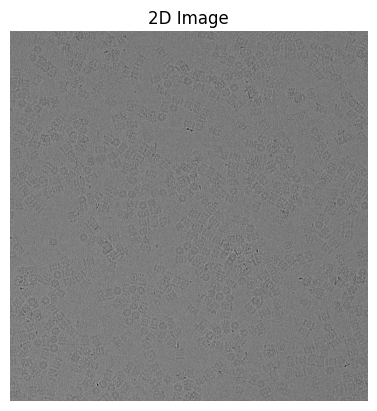

In [ ]:
file_id = "1Qj30jSXcHEpkzE04cisbP6ljtnQ2Ausr"
output = "map.mrc"

print("Downloading MRC file...")
gdown.download(id=file_id, output=output, quiet=False)


file_size = os.path.getsize(output)
print(f"\nFile size: {file_size / (1024**2):.2f} MB")

with open(output, "rb") as f:
    header = f.read(4)

print("First 4 bytes:", header)

if header.startswith(b"<"):
    raise ValueError("❌ Downloaded file is HTML, not MRC. Check sharing permissions.")

if file_size < 10000:
    raise ValueError("❌ File too small — likely incorrect download.")

print("✓ File appears valid")

print("\nLoading MRC file...")

with mrcfile.open(output, permissive=True) as mrc:
    if mrc.data is None:
        raise ValueError("❌ MRC file contains no readable data")
    data = mrc.data.copy()

print("✓ MRC loaded successfully")

print("\n" + "="*60)
print("MRC DATA INFO")
print("="*60)
print("Shape:", data.shape)
print("Dtype:", data.dtype)
print("Min/Max:", data.min(), data.max())


if data.ndim == 3:
    print("\nDetected: 3D volume")

    z, y, x = np.array(data.shape) // 2

    # ------------------------------------------
    # CENTRAL SLICES (RAW)
    # ------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    slices = [
        (data[z, :, :], "XY slice"),
        (data[:, y, :], "XZ slice"),
        (data[:, :, x], "YZ slice"),
    ]

    for ax, (img, title) in zip(axes, slices):
        vmin = np.percentile(img, 5)
        vmax = np.percentile(img, 95)
        ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

    print("\nGenerating summed projections...")

    proj_xy = np.sum(data, axis=0)
    proj_xz = np.sum(data, axis=1)
    proj_yz = np.sum(data, axis=2)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    projections = [
        (proj_xy, "XY Projection (sum Z)"),
        (proj_xz, "XZ Projection (sum Y)"),
        (proj_yz, "YZ Projection (sum X)")
    ]

    for ax, (proj, title) in zip(axes, projections):
        vmin = np.percentile(proj, 5)
        vmax = np.percentile(proj, 95)
        ax.imshow(proj, cmap='gray', vmin=vmin, vmax=vmax)
        ax.set_title(title)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

elif data.ndim == 2:
    print("\nDetected: single 2D image")

    vmin = np.percentile(data, 5)
    vmax = np.percentile(data, 95)

    plt.imshow(data, cmap='gray', vmin=vmin, vmax=vmax)
    plt.title("2D Image")
    plt.axis('off')
    plt.show()

else:
    print("\n⚠️ Unrecognized format")

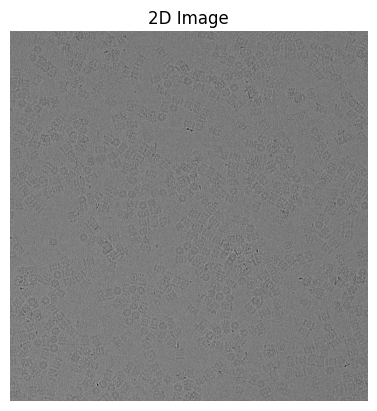

In [ ]:
data
plt.imshow(data, cmap='gray', vmin=vmin, vmax=vmax)
plt.title("2D Image")
plt.axis('off')
plt.show()




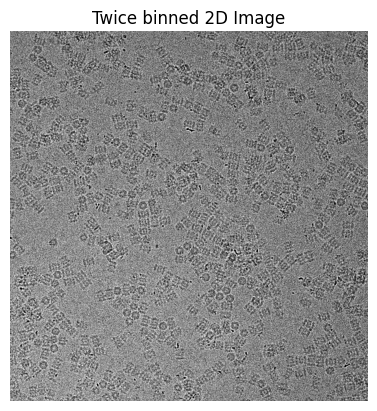

In [ ]:
def bin_image(image, bin_size):
    """
    Performs binning (spatial downsampling) on an image.

    Args:
        image: Input image as numpy array
        bin_size: Size of the bin (e.g., 2 for 2x2 binning)

    Returns:
        Binned image with reduced resolution
    """
    h, w = image.shape
    # Calculate new dimensions
    new_h = h // bin_size
    new_w = w // bin_size

    # Reshape and compute mean of each bin
    binned = image[:new_h*bin_size, :new_w*bin_size].reshape(new_h, bin_size, new_w, bin_size)
    binned = binned.mean(axis=(1, 3)).astype(np.uint8)

    return binned

binned_data = bin_image(data, 5)
plt.imshow(bin_image(data, 5), cmap='gray', vmin=np.percentile(binned_data, 5), vmax=np.percentile(binned_data, 95))
plt.title("Twice binned 2D Image")
plt.axis('off')
plt.show()

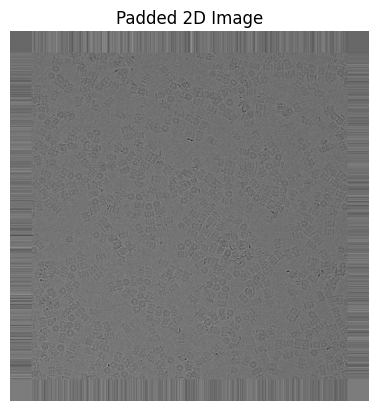

In [ ]:


def apply_padding(img, pad_width, mode='constant', constant_value=255):
    """
    Apply padding to an image using NumPy.

    Parameters:
    -----------
    img : ndarray
        Input image
    pad_width : int or tuple
        Number of pixels to pad on each side
    mode : str
        Padding mode: 'constant', 'edge', 'reflect', 'wrap'
    constant_value : int
        Value used for constant padding

    Returns:
    --------
    padded : ndarray
        Padded image
    """
    if isinstance(pad_width, int):
        pad_width = ((pad_width, pad_width), (pad_width, pad_width))

    if mode == 'constant':
        padded = np.pad(img, pad_width, mode='constant', constant_values=constant_value)
    else:
        padded = np.pad(img, pad_width, mode=mode)

    return padded

padded_data = apply_padding(binned_data, 100, 'edge')
plt.imshow(padded_data, cmap='gray', vmin=np.percentile(data, 5), vmax=np.percentile(data, 95))
plt.title("Padded 2D Image")
plt.axis('off')
plt.show()


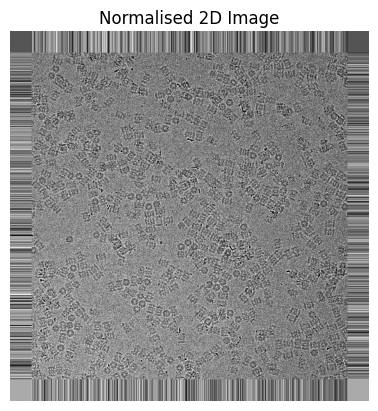

In [ ]:

normalised_data = padded_data / data.max()
plt.imshow(normalised_data, cmap='gray', vmin=np.percentile(normalised_data, 5), vmax=np.percentile(normalised_data, 95))
plt.title("Normalised 2D Image")
plt.axis('off')
plt.show()

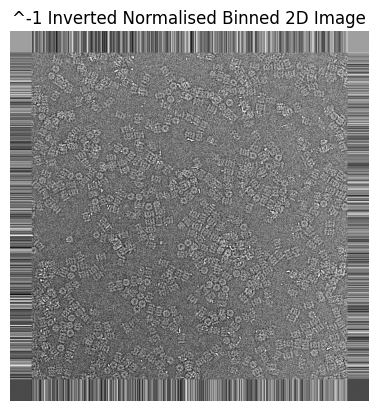

In [ ]:
inverted_normalised_binned_data =1/normalised_data
plt.imshow(inverted_normalised_binned_data, cmap='gray', vmin=np.percentile(inverted_normalised_binned_data, 5), vmax=np.percentile(inverted_normalised_binned_data, 95))
plt.title("^-1 Inverted Normalised Binned 2D Image")
plt.axis('off')
plt.show()

#inverted_normalised_binned_data =-1*normalised_binned_data
#plt.imshow(inverted_normalised_binned_data, cmap='gray', vmin=np.percentile(inverted_normalised_binned_data, 5), vmax=np.percentile(inverted_normalised_binned_data, 95))
#plt.title("*-1 Inverted Normalised Binned 2D Image")
#plt.axis('off')
#plt.show()

Successfully downloaded 3885327 bytes
Saved to 6BDF.pdb

Coordinate statistics:
  X range: [87.952, 207.696] Å
  Y range: [86.677, 207.946] Å
  Z range: [64.854, 229.751] Å


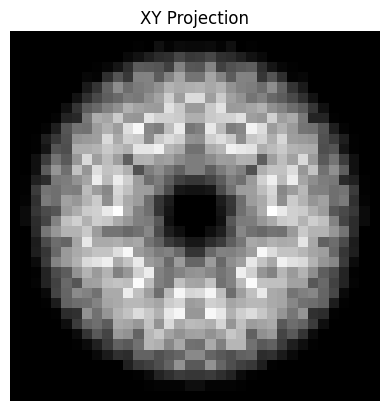

<Figure size 640x480 with 0 Axes>

In [ ]:
pdb_id = "6BDF"
pdb_url = f"https://files.rcsb.org/download/{pdb_id}.pdb"

try:
    print(f"Downloading {pdb_id} from RCSB PDB...")
    with urllib.request.urlopen(pdb_url, timeout=10) as response:
        pdb_content = response.read().decode('utf-8')
    print(f"Successfully downloaded {len(pdb_content)} bytes")

    # Save to file
    pdb_file = f"{pdb_id}.pdb"
    with open(pdb_file, 'w') as f:
        f.write(pdb_content)
    print(f"Saved to {pdb_file}")

    # Parse the PDB file
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure(pdb_id, pdb_file)

    # Extract information
    model = structure[0]
    chains = list(model.get_chains())


    all_atoms = []
    for chain in model.get_chains():
        for residue in chain.get_residues():
            for atom in residue.get_atoms():
                coord = atom.get_coord()
                all_atoms.append({
                    'name': atom.name,
                    'residue': residue.resname,
                    'residue_id': residue.id[1],
                    'x': coord[0],
                    'y': coord[1],
                    'z': coord[2],
                    'b_factor': atom.bfactor
                })


    coords = np.array([[atom['x'], atom['y'], atom['z']] for atom in all_atoms])


    print(f"\nCoordinate statistics:")
    print(f"  X range: [{coords[:, 0].min():.3f}, {coords[:, 0].max():.3f}] Å")
    print(f"  Y range: [{coords[:, 1].min():.3f}, {coords[:, 1].max():.3f}] Å")
    print(f"  Z range: [{coords[:, 2].min():.3f}, {coords[:, 2].max():.3f}] Å")


    # Center coordinates
    coords_centered = coords - coords.mean(axis=0)

    # Resolution of projection image
    img_size = 36  # pixels
    padding = 5     # Å padding around structure

    # Function to create summed projection
    def create_projection(coord1, coord2, bins=256):
        # Determine bounds
        min1, max1 = coord1.min() - padding, coord1.max() + padding
        min2, max2 = coord2.min() - padding, coord2.max() + padding

        # 2D histogram (counts = density)
        H, xedges, yedges = np.histogram2d(coord1, coord2, bins=bins,
                                        range=[[min1, max1], [min2, max2]])

        # Normalize for display
        H = H / H.max()

        return H

    # Create projections
    proj_xy = create_projection(coords_centered[:, 0], coords_centered[:, 1], img_size)
    # Plot projections
    plt.imshow(proj_xy, cmap='gray')
    plt.title("XY Projection")
    plt.axis('off')
    plt.show()


    plt.tight_layout()
    plt.show()

except urllib.error.URLError as e:
    print(f"Error downloading PDB file: {e}")
    print("   Make sure you have internet connection")
except Exception as e:
    print(f"Error: {type(e).__name__}: {e}")

In [ ]:
def normalized_cross_correlation(image, template):
    """
    Perform normalized cross-correlation.

    Parameters:
    -----------
    image : 2D numpy array
        Input image
    template : 2D numpy array
        Template to search for

    Returns:
    --------
    output : 2D numpy array
        Normalized cross-correlation (values between -1 and 1)
    """
    img_h, img_w = image.shape
    tmp_h, tmp_w = template.shape

    out_h = img_h - tmp_h + 1
    out_w = img_w - tmp_w + 1

    output = np.zeros((out_h, out_w))

    # Normalize template (subtract mean)
    template_mean = template.mean()
    template_norm = template - template_mean
    template_std = np.sqrt(np.sum(template_norm ** 2))

    # Avoid division by zero
    if template_std == 0:
        return output

    # Slide template over image
    for i in range(out_h):
        for j in range(out_w):
            region = image[i:i+tmp_h, j:j+tmp_w]

            # Normalize region
            region_mean = region.mean()
            region_norm = region - region_mean
            region_std = np.sqrt(np.sum(region_norm ** 2))

            # Avoid division by zero
            if region_std == 0:
                output[i, j] = 0
            else:
                # Normalized cross-correlation
                output[i, j] = np.sum(region_norm * template_norm) / (region_std * template_std)

    return output


def template_matching(image, template, method='ncc'):
    """
    Perform template matching with padding.

    Parameters:
    -----------
    image : 2D numpy array
        Input image
    template : 2D numpy array
        Template to search for
    method : str
        'ncc' for normalized cross-correlation
        'cc' for simple cross-correlation

    Returns:
    --------
    result : 2D numpy array (same size as input image)
        Matching score map
    """
    tmp_h, tmp_w = template.shape
    pad_h, pad_w = tmp_h // 2, tmp_w // 2

    # Pad image
    padded = np.pad(image,
                    ((pad_h, pad_h), (pad_w, pad_w)),
                    mode='constant',
                    constant_values=0)

    # Perform matching
    if method == 'ncc':
        result = normalized_cross_correlation(padded, template)
    else:
        result = cross_correlation(padded, template)

    return result

match_result = template_matching(inverted_normalised_binned_data, proj_xy, method='ncc')


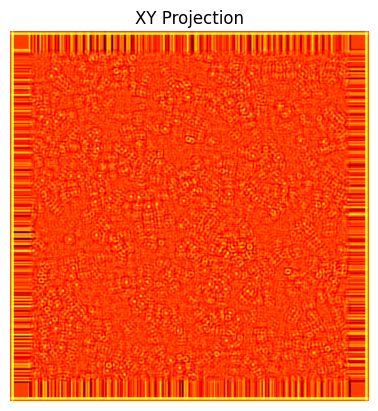

In [ ]:
plt.imshow(match_result, cmap='hot')
plt.title("XY Projection")
plt.axis('off')
plt.show()

Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
    (1575, 12) - Score: 0.3484
    (1575, 13) - Score: 0.3542
    (1575, 14) - Score: 0.3492
    (1575, 15) - Score: 0.3257
    (1575, 1671) - Score: 0.3315
    (1575, 1672) - Score: 0.3280
    (1576, 11) - Score: 0.3337
    (1576, 12) - Score: 0.3530
    (1576, 13) - Score: 0.3592
    (1576, 14) - Score: 0.3545
    (1576, 15) - Score: 0.3318
    (1576, 1671) - Score: 0.3255
    (1577, 11) - Score: 0.3299
    (1577, 12) - Score: 0.3489
    (1577, 13) - Score: 0.3547
    (1577, 14) - Score: 0.3491
    (1577, 15) - Score: 0.3250
    (1578, 11) - Score: 0.3252
    (1578, 12) - Score: 0.3437
    (1578, 13) - Score: 0.3488
    (1578, 14) - Score: 0.3426
    (1579, 12) - Score: 0.3394
    (1579, 13) - Score: 0.3441
    (1579, 14) - Score: 0.3372
    (1580, 12) - Score: 0.3329
    (1580, 13) - Score: 0.3366
    (1580, 14) - Score: 0.3287
    (1581, 12) - Score: 0.3295
    (1581, 13) - Score: 0.3330
    (1581, 14) - 

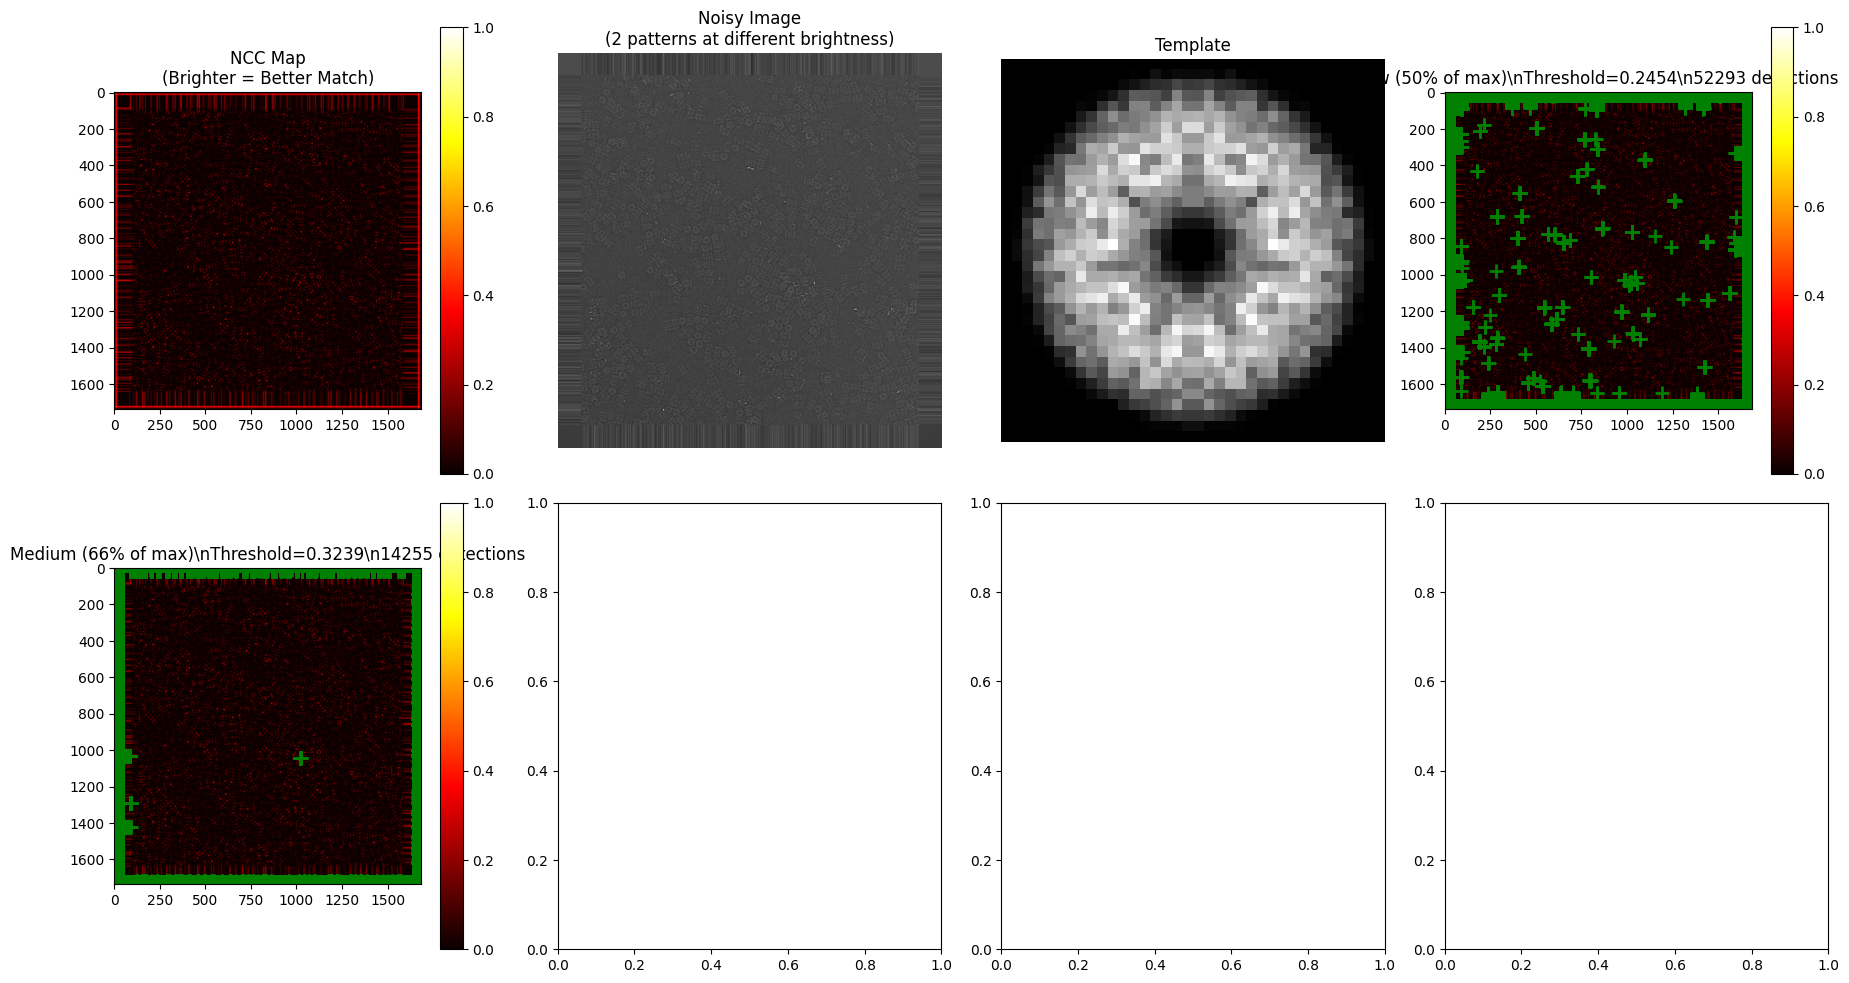

In [ ]:
print("NCC Matching Map Statistics:")
print(f"Min value: {match_result.min():.4f}")
print(f"Max value: {match_result.max():.4f}")
print(f"Mean value: {match_result.mean():.4f}")
print(f"Std deviation: {match_result.std():.4f}")

# Try different threshold strategies
thresholds = {
    'Low (50% of max)': 0.5 * match_result.max(), 'Medium (66% of max)': 0.66* match_result.max() # , add here thresholds you want to try
}

# Visualize effect of different thresholds
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.ravel()

# Show original NCC map
im0 = axes[0].imshow(match_result, cmap='hot', vmin=0, vmax=1)
axes[0].set_title('NCC Map\n(Brighter = Better Match)')
plt.colorbar(im0, ax=axes[0])

# Show noisy image with patterns for reference
axes[1].imshow(inverted_normalised_binned_data, cmap='gray')
axes[1].set_title('Noisy Image\n(2 patterns at different brightness)')
axes[1].axis('off')

# Show template
axes[2].imshow(proj_xy, cmap='gray')
axes[2].set_title('Template')
axes[2].axis('off')

# Apply each threshold
for idx, (name, thresh_value) in enumerate(thresholds.items()):
    ax = axes[idx + 3]

    # Find matches above threshold
    detected_y, detected_x = np.where(match_result > thresh_value)

    # Print detected peak coordinates
    print(f"\n{name} (Threshold = {thresh_value:.4f}):")
    print(f"  Number of detections: {len(detected_x)}")
    if len(detected_x) > 0:
        print(f"  Peak coordinates (y, x):")
        for y, x in zip(detected_y, detected_x):
            score = match_result[y, x]
            print(f"    ({y}, {x}) - Score: {score:.4f}")
    else:
        print("  No peaks detected")

    # Show NCC map with detected matches
    im = ax.imshow(match_result, cmap='hot', vmin=0, vmax=1)

    # Mark detected matches with green crosses
    ax.plot(detected_x, detected_y, 'g+',
            markersize=10, markeredgewidth=2)

    ax.set_title(f'{name}\\nThreshold={thresh_value:.4f}\\n{len(detected_x)} detections')
    plt.colorbar(im, ax=ax)

plt.tight_layout()
plt.show()

NCC Matching Map Statistics (Excluding 100px Padding):
Min value: -0.2750
Max value: 0.3653
Mean value: -0.0002
Std deviation: 0.0517

Low (50% of max) (Threshold = 0.1827):
  Number of detections: 193
  Peak coordinates (y, x):
    (1042, 1021) - Score: 0.3653
    (552, 413) - Score: 0.3100
    (820, 1437) - Score: 0.3092
    (1179, 545) - Score: 0.3065
    (766, 1028) - Score: 0.3020
    (1321, 1032) - Score: 0.3019
    (1244, 612) - Score: 0.3012
    (1580, 796) - Score: 0.2991
    (1379, 282) - Score: 0.2932
    (1611, 537) - Score: 0.2910
    (1367, 190) - Score: 0.2909
    (800, 400) - Score: 0.2897
    (679, 423) - Score: 0.2893
    (957, 406) - Score: 0.2871
    (256, 766) - Score: 0.2865
    (778, 604) - Score: 0.2814
    (1112, 299) - Score: 0.2813
    (1220, 1115) - Score: 0.2811
    (1593, 456) - Score: 0.2809
    (1405, 787) - Score: 0.2800
    (457, 727) - Score: 0.2782
    (1202, 969) - Score: 0.2779
    (1099, 1561) - Score: 0.2755
    (367, 1098) - Score: 0.2745
    (1

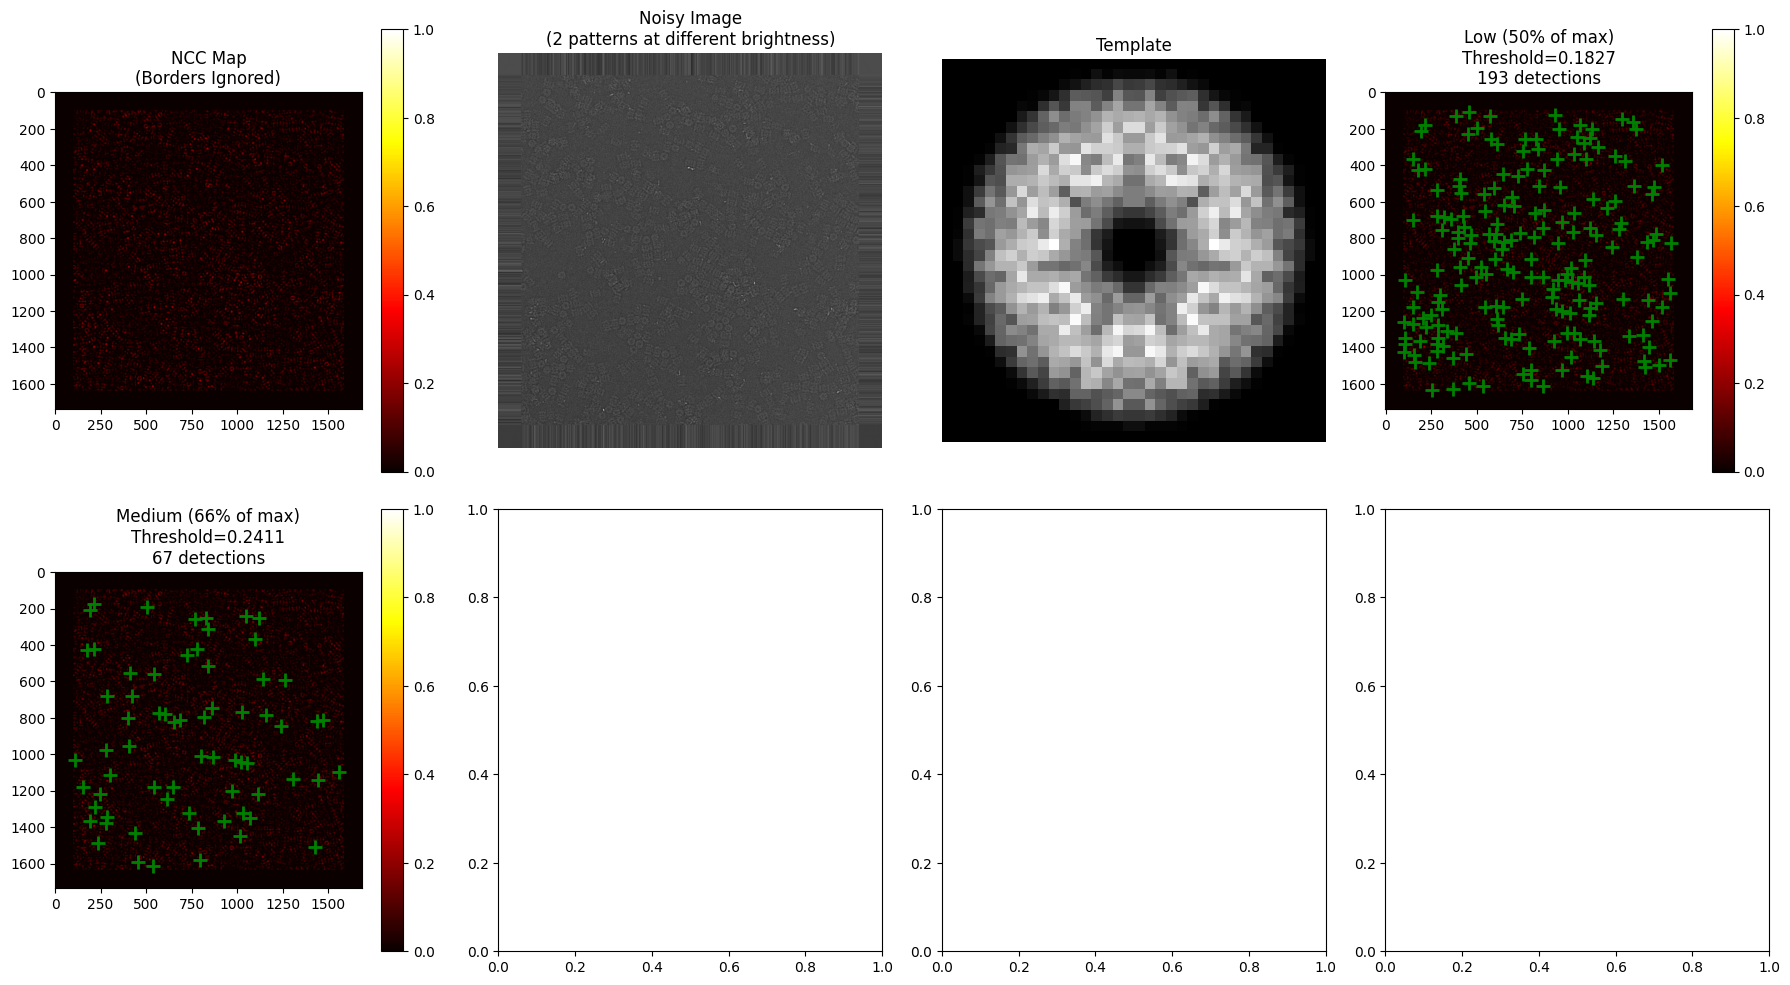

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import peak_local_max

# --- 1. IGNORE PADDING PIXELS ---
padding = 100
# Create a copy so we don't destructively modify the original NCC map
processed_match = match_result.copy()

# Set the 100-pixel border on all sides to -1.0 (lowest possible NCC score)
processed_match[:padding, :] = -1.0
processed_match[-padding:, :] = -1.0
processed_match[:, :padding] = -1.0
processed_match[:, -padding:] = -1.0

# Calculate stats only on the valid inner region
inner_region = match_result[padding:-padding, padding:-padding]

print("NCC Matching Map Statistics (Excluding 100px Padding):")
print(f"Min value: {inner_region.min():.4f}")
print(f"Max value: {inner_region.max():.4f}")
print(f"Mean value: {inner_region.mean():.4f}")
print(f"Std deviation: {inner_region.std():.4f}")

# Try different threshold strategies based on the valid inner region
thresholds = {
    'Low (50% of max)': 0.5 * inner_region.max(),
    'Medium (66% of max)': 0.66 * inner_region.max()
}

# Visualize effect of different thresholds
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.ravel()

# Show padded NCC map
im0 = axes[0].imshow(processed_match, cmap='hot', vmin=0, vmax=1)
axes[0].set_title('NCC Map\n(Borders Ignored)')
plt.colorbar(im0, ax=axes[0])

# Show noisy image with patterns for reference
axes[1].imshow(inverted_normalised_binned_data, cmap='gray')
axes[1].set_title('Noisy Image\n(2 patterns at different brightness)')
axes[1].axis('off')

# Show template
axes[2].imshow(proj_xy, cmap='gray')
axes[2].set_title('Template')
axes[2].axis('off')

# --- 2. FIX CLUSTERING (Peak Extraction) ---
# Set min_distance to roughly the width/height of your template pattern
# to ensure it only grabs one peak per distinct object zone.
min_separation = 30

# Apply each threshold
for idx, (name, thresh_value) in enumerate(thresholds.items()):
    ax = axes[idx + 3]

    # peak_local_max replaces np.where. It forces a minimum distance between detections.
    coordinates = peak_local_max(
        processed_match,
        min_distance=min_separation,
        threshold_abs=thresh_value
    )

    print(f"\n{name} (Threshold = {thresh_value:.4f}):")
    print(f"  Number of detections: {len(coordinates)}")

    if len(coordinates) > 0:
        print(f"  Peak coordinates (y, x):")
        # peak_local_max returns an array of [y, x] pairs
        for y, x in coordinates:
            score = processed_match[y, x]
            print(f"    ({y}, {x}) - Score: {score:.4f}")

        # Extract y and x arrays for plotting the green crosses
        detected_y = coordinates[:, 0]
        detected_x = coordinates[:, 1]
    else:
        print("  No peaks detected")
        detected_y, detected_x = [], []

    # Show NCC map with detected matches
    im = ax.imshow(processed_match, cmap='hot', vmin=0, vmax=1)

    # Mark detected matches with green crosses
    if len(coordinates) > 0:
        ax.plot(detected_x, detected_y, 'g+', markersize=10, markeredgewidth=2)

    ax.set_title(f'{name}\nThreshold={thresh_value:.4f}\n{len(coordinates)} detections')
    plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

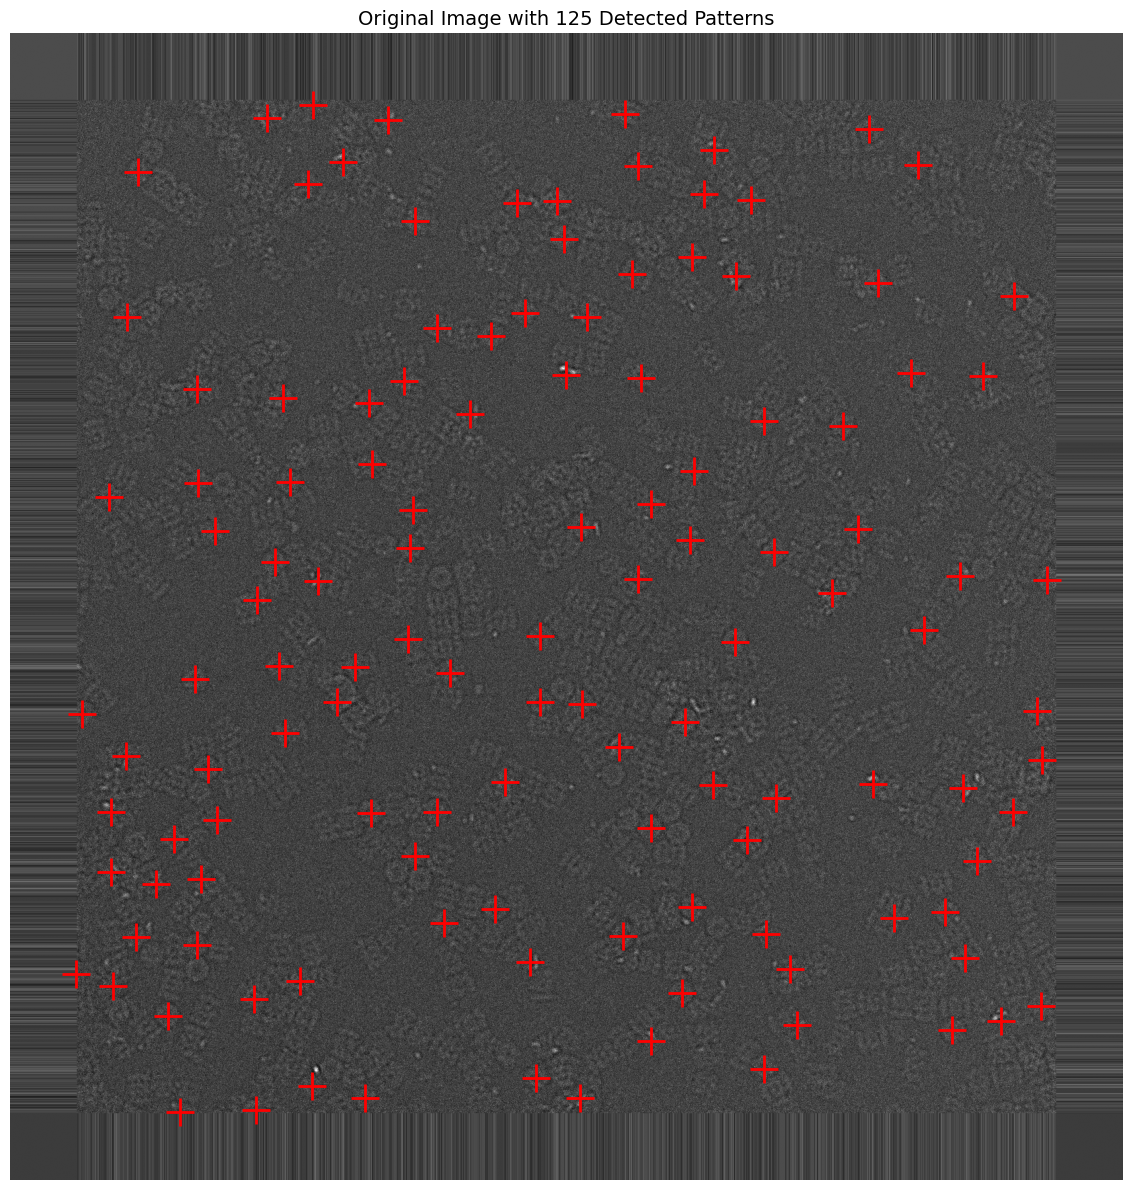

In [ ]:

# --- 1. SET YOUR CHOSEN THRESHOLD ---
# Using the max value from the inner region calculated in the previous cell
chosen_threshold = 0.5 * inner_region.max()

# Extract the final coordinates
final_coordinates = peak_local_max(
    processed_match,
    min_distance=50,
    threshold_abs=chosen_threshold
)

# --- 2. PLOT ON ORIGINAL IMAGE ---
plt.figure(figsize=(12, 12))
plt.imshow(inverted_normalised_binned_data, cmap='gray')

if len(final_coordinates) > 0:
    detected_y = final_coordinates[:, 0]
    detected_x = final_coordinates[:, 1]

    # Plot red crosses (markersize and width increased for visibility)
    plt.plot(detected_x, detected_y, 'r+', markersize=20, markeredgewidth=2)
    plt.title(f'Original Image with {len(final_coordinates)} Detected Patterns', fontsize=14)
else:
    plt.title('No patterns detected at this threshold.', fontsize=14)

plt.axis('off')
plt.tight_layout()
plt.show()

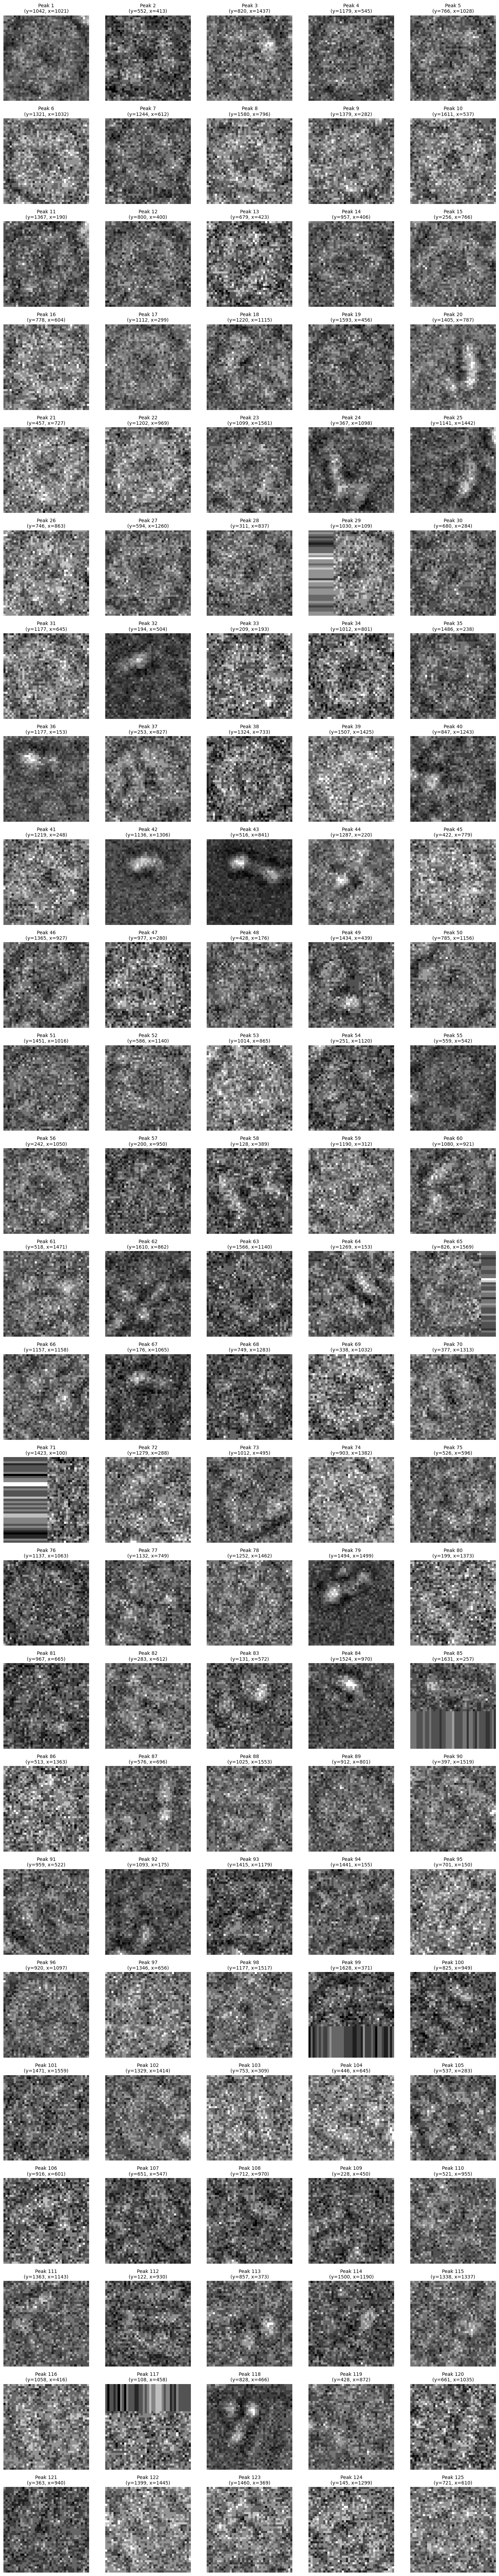

In [ ]:
# Define the size of the box you want to cut out
patch_size = 40
half_size = patch_size // 2

num_peaks = len(final_coordinates)

if num_peaks > 0:
    # Dynamically size the gallery (up to 5 columns wide)
    cols = min(5, num_peaks)
    rows = int(np.ceil(num_peaks / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))

    # If there's only 1 peak, matplotlib doesn't return an array of axes, so we force it
    if num_peaks == 1:
        axes = np.array([axes])
    axes = axes.ravel()

    for i, (y, x) in enumerate(final_coordinates):
        # Calculate the bounding box (with safety checks in case a peak is near the absolute edge)
        y_start = max(0, y - half_size)
        y_end = min(inverted_normalised_binned_data.shape[0], y + half_size + 1)
        x_start = max(0, x - half_size)
        x_end = min(inverted_normalised_binned_data.shape[1], x + half_size + 1)

        # Slice the patch out of the original raw image
        patch = inverted_normalised_binned_data[y_start:y_end, x_start:x_end]

        # Plot it
        axes[i].imshow(patch, cmap='gray')
        axes[i].set_title(f'Peak {i+1}\n(y={y}, x={x})', fontsize=10)
        axes[i].axis('off')

    # Shut off any empty subplots in the final row
    for j in range(num_peaks, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No peaks detected! Lower the threshold to see patches.")

In [ ]:
requirements = [
    'numpy',
    'matplotlib',
    'opencv-python',
    'tifffile',
    'scipy',
    'Pillow',
    'requests',
    'scikit-image',
    'biopython',
    'mrcfile',
    'gdown'
]

with open('requirements.txt', 'w') as f:
    for lib in requirements:
        f.write(f'{lib}\n')

print('✓ requirements.txt has been created.')

✓ requirements.txt has been created.
